# AICE 모의고사 1회 - 학생 성적 예측

## 문제 시나리오

학생들의 인구통계학적 정보와 학습 데이터를 분석하고 최종 성적을 예측하는 모델을 작성하세요.

---

## 1-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

다음의 데이터를 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터를 읽어 데이터프레임으로 할당하는 코드를 작성하세요.

- `student_demographics.csv` 파일을 읽어 데이터프레임 변수 `df_demographics`에 할당하세요.
- `course_grades.json` 파일을 읽어 데이터프레임 변수 `df_grades`에 할당하세요.

In [120]:
## 라이브러리 임포트
import pandas as pd
df_demographics = pd.read_csv('C:/juehyeon/aice_test/기출문제/1.학생성적예측/student_demographics.csv')
df_grades = pd.read_json('C:/juehyeon/aice_test/기출문제/1.학생성적예측/course_grades_1.json')

In [121]:
## 데이터 확인
df_grades.info() # 결측치 확인 : StudentID 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     98 non-null     float64
 1   MidtermScore  100 non-null    int64  
 2   QuizAverage   100 non-null    int64  
 3   ProjectScore  100 non-null    int64  
 4   FinalScore    100 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 4.0 KB


In [122]:
df_demographics.info() ## 결측치 확인 : ParentalEducation, Absences

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   StudentID            100 non-null    int64  
 1   Age                  100 non-null    int64  
 2   Gender               100 non-null    object 
 3   ParentalEducation    94 non-null     object 
 4   StudyHours_per_week  100 non-null    int64  
 5   Absences             95 non-null     float64
 6   PreviousGPA          100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


## 1-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

두 개의 데이터프레임(`df_demographics`, `df_grades`)을 StudentID 컬럼을 기준으로 병합하고, 병합된 데이터프레임의 상위 5개 행과 컬럼별 요약 정보를 출력하여 2개 데이터를 탐색하는 코드를 작성하세요.

`pandas`의 merge 함수를 사용하여 `df_demographics`와 `df_grades`를 StudentID를 키(key)로 병합하고 df 변수에 저장하세요.
    - 병합 방식은 inner로 지정하세요.
    - df 데이터프레임의 상위 5 개 행을 출력하세요.
    - df 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.

In [123]:
## 데이터 병합하기 - merge(데이터1(l), 데이터2(r), on = '기준컬럼', how = '병합방식')
df = pd.merge(df_demographics, df_grades, on = 'StudentID', how = 'inner')

In [124]:
## 병합 데이터 확인하기 
df.info() # 결측치 존재 -> ParentalEducation, Absences

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   StudentID            98 non-null     int64  
 1   Age                  98 non-null     int64  
 2   Gender               98 non-null     object 
 3   ParentalEducation    92 non-null     object 
 4   StudyHours_per_week  98 non-null     int64  
 5   Absences             93 non-null     float64
 6   PreviousGPA          98 non-null     float64
 7   MidtermScore         98 non-null     int64  
 8   QuizAverage          98 non-null     int64  
 9   ProjectScore         98 non-null     int64  
 10  FinalScore           98 non-null     int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 8.6+ KB


In [125]:
## 상위 5개행 출력 -> .head()
df.head()

,StudentID,Age,Gender,ParentalEducation,StudyHours_per_week,Absences,PreviousGPA,MidtermScore,QuizAverage,ProjectScore,FinalScore
0,1,17,Female,University,39,22.0,3.52,55,85,98,94
1,2,18,Male,HighSchool,52,1.0,2.03,55,96,97,71
2,3,16,Male,College,29,9.0,2.23,70,65,70,97
3,4,18,Female,HighSchool,39,1.0,2.09,53,89,75,79
4,5,18,Female,HighSchool,29,16.0,2.08,80,83,73,52


## 1-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

ParentalEducation 컬럼의 분포를 시각화하고, 데이터 경제를 위해 'N/A' 값을 가진 행을 제거하는 코드를 작성하세요.

- seaborn 라이브러리의 countplot을 사용하여 ParentalEducation 컬럼의 분포를 시각화하세요.
- ParentalEducation 컬럼 값이 'N/A'인 행을 데이터프레임에서 삭제하세요.

In [126]:
## 라이브러리 임포트
import seaborn as sns 
 

<Axes: xlabel='ParentalEducation', ylabel='count'>

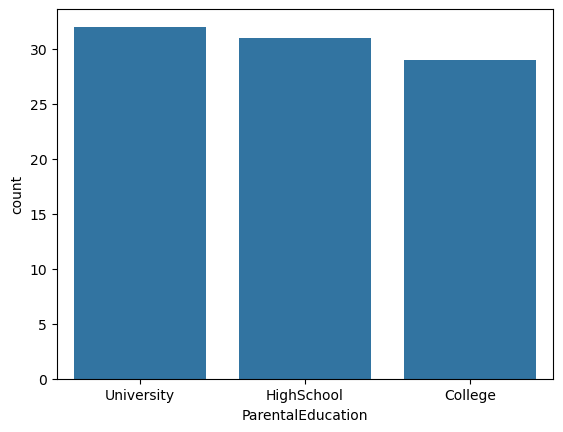

In [127]:
## 데이터 시각화
sns.countplot(data = df, x = 'ParentalEducation')

In [128]:
# N/A 삭제
df = df[df['ParentalEducation'] != 'N/A']

In [129]:
# N/A삭제 확인
(df['ParentalEducation'] == 'N/A').sum()

np.int64(0)

## 1-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

StudyHours_per_week와 FinalScore 간의 관계를 jointplot으로 시각화하고, StudyHours_per_week가 50 이상인 이상치 값의 개수를 확인하는 코드를 작성하세요.

- seaborn 라이브러리의 jointplot을 사용하여 x축에 StudyHours_per_week, y축에 FinalScore를 표시하세요.
- StudyHours_per_week가 50 이상인 행의 개수를 세어 출력하세요.

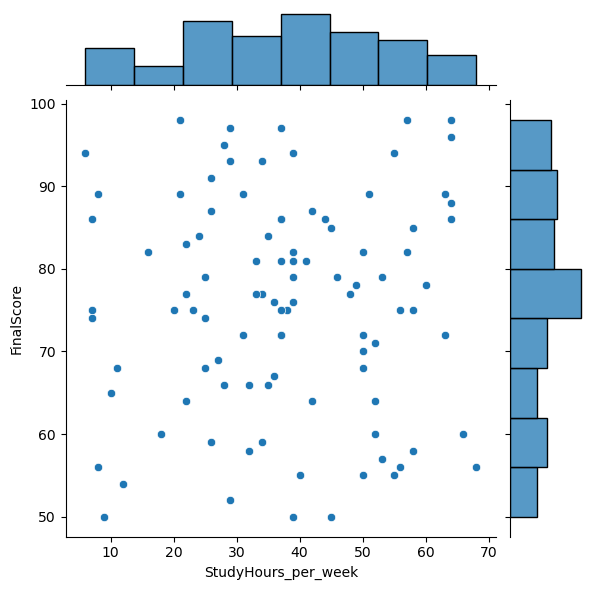

In [130]:
# 데이터 시각화
sns.jointplot(data = df, x = 'StudyHours_per_week', y ='FinalScore')

In [131]:
# StudyHours_per_week가 50이상인 행 개수 세기
print((df['StudyHours_per_week'] >= 50).sum())

29


## 1-5 | 이상치 및 결측인 컬럼 처리

### 【 문제 】

StudyHours_per_week가 50 이상인 이상치 행을 삭제하고, 모델링에 불필요한 StudentID 컬럼을 삭제하는 코드를 작성하세요.

- StudyHours_per_week가 50 미만인 행만 남기고 데이터프레임을 업데이트하세요.
- StudentID 컬럼을 데이터프레임에서 삭제하세요.
- 변경된 데이터프레임을 새로운 변수 df_cleaned에 저장하세요.

In [132]:
# 이상치 삭제 
df = df[df['StudyHours_per_week'] < 50]

In [133]:
# 이상치 삭제 확인하기
print((df['StudyHours_per_week'] >= 50).sum())

0


In [134]:
# 컬럼 삭제 .drop()
df_cleaned = df.drop(columns = 'StudentID', axis = 1)

In [135]:
# 컬럼 삭제 확인
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69 entries, 0 to 97
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  69 non-null     int64  
 1   Gender               69 non-null     object 
 2   ParentalEducation    66 non-null     object 
 3   StudyHours_per_week  69 non-null     int64  
 4   Absences             65 non-null     float64
 5   PreviousGPA          69 non-null     float64
 6   MidtermScore         69 non-null     int64  
 7   QuizAverage          69 non-null     int64  
 8   ProjectScore         69 non-null     int64  
 9   FinalScore           69 non-null     int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 5.9+ KB


## 1-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

데이터프레임에 결측치가 있는지 확인하고, 결측치가 있는 행을 삭제한 뒤, Absences 컬럼을 정수형(int)으로 변환하세요.

- `df_cleaned`의 결측치를 확인하는 코드를 작성하세요.
- 결측치가 있는 모든 행을 삭제하세요.
- Absences 컬럼의 데이터 타입을 int로 변환하세요.
- 변경된 데이터프레임을 `df_processed` 변수에 저장하세요.

In [136]:
# 결측치 확인하기 .isna().sum()
df_cleaned.isna().sum()

Age                    0
Gender                 0
ParentalEducation      3
StudyHours_per_week    0
Absences               4
PreviousGPA            0
MidtermScore           0
QuizAverage            0
ProjectScore           0
FinalScore             0
dtype: int64

In [137]:
# 결측치 있는 행 삭제하기 .dropna()
df_cleaned = df_cleaned.dropna(axis = 0)

In [138]:
# 결측치 삭제 확인 
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 97
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  62 non-null     int64  
 1   Gender               62 non-null     object 
 2   ParentalEducation    62 non-null     object 
 3   StudyHours_per_week  62 non-null     int64  
 4   Absences             62 non-null     float64
 5   PreviousGPA          62 non-null     float64
 6   MidtermScore         62 non-null     int64  
 7   QuizAverage          62 non-null     int64  
 8   ProjectScore         62 non-null     int64  
 9   FinalScore           62 non-null     int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 5.3+ KB


In [139]:
# 데이터타입변경
df_cleaned['Absences'] = df_cleaned['Absences'].astype(int)

In [140]:
# 데이터 타입 변경 확인
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 97
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  62 non-null     int64  
 1   Gender               62 non-null     object 
 2   ParentalEducation    62 non-null     object 
 3   StudyHours_per_week  62 non-null     int64  
 4   Absences             62 non-null     int64  
 5   PreviousGPA          62 non-null     float64
 6   MidtermScore         62 non-null     int64  
 7   QuizAverage          62 non-null     int64  
 8   ProjectScore         62 non-null     int64  
 9   FinalScore           62 non-null     int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 5.3+ KB


In [141]:
# 데이터프레임 재할당
df_processed = df_cleaned.copy()

## 1-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

컬럼을 삭제하고, object 타입의 범주형 컬럼(Gender, ParentalEducation)을 원-핫 인코딩하세요.

- `df_processed`에서 Age 컬럼을 삭제하세요.
- pandas의 get_dummies 함수를 활용하여 object 타입의 컬럼에 대해 원-핫 인코딩을 수행하세요.
- 변경된 컬럼명 `df_encoded` 변수에 저장하세요.

In [142]:
# Age 컬럼 삭제 전
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 97
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  62 non-null     int64  
 1   Gender               62 non-null     object 
 2   ParentalEducation    62 non-null     object 
 3   StudyHours_per_week  62 non-null     int64  
 4   Absences             62 non-null     int64  
 5   PreviousGPA          62 non-null     float64
 6   MidtermScore         62 non-null     int64  
 7   QuizAverage          62 non-null     int64  
 8   ProjectScore         62 non-null     int64  
 9   FinalScore           62 non-null     int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 5.3+ KB


In [143]:
# age 컬럼 삭제
df_processed = df_processed.drop(columns = 'Age', axis = 1)

In [144]:
# 삭제 확인
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 97
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               62 non-null     object 
 1   ParentalEducation    62 non-null     object 
 2   StudyHours_per_week  62 non-null     int64  
 3   Absences             62 non-null     int64  
 4   PreviousGPA          62 non-null     float64
 5   MidtermScore         62 non-null     int64  
 6   QuizAverage          62 non-null     int64  
 7   ProjectScore         62 non-null     int64  
 8   FinalScore           62 non-null     int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 4.8+ KB


In [145]:
# 원-핫 인코딩
incod_cols = ['Gender', 'ParentalEducation']
df_encoded = pd.get_dummies(data = df_processed, columns = incod_cols)

In [146]:
# 인코딩 확인\
df_encoded.head()

,StudyHours_per_week,Absences,PreviousGPA,MidtermScore,QuizAverage,ProjectScore,FinalScore,Gender_Female,Gender_Male,ParentalEducation_College,ParentalEducation_HighSchool,ParentalEducation_University
0,39,22,3.52,55,85,98,94,True,False,False,False,True
2,29,9,2.23,70,65,70,97,False,True,True,False,False
3,39,1,2.09,53,89,75,79,True,False,False,True,False
4,29,16,2.08,80,83,73,52,True,False,False,True,False
7,22,10,2.20,98,89,66,64,False,True,False,False,True


## 1-8 | 데이터 분리 및 스케일링

### 【 문제 】

최종 성적(FinalScore)을 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.

- FinalScore 컬럼을 y 변수에, 나머지 컬럼을 X 변수에 할당하세요.
- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)로 분리하세요. random_state는 42로 설정하세요.
- sklearn.preprocessing의 RobustScaler를 사용하여 훈련 데이터와의 Feature(X_train)를 스케일링하고 X_train_scaled에 할당하세요.
- RobustScaler의 transform 함수를 사용하여 검증 데이터와의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.

In [147]:
# 데이터 분리하기 
X = df_encoded.drop(columns = 'FinalScore')
y = df_encoded['FinalScore']

In [148]:
# 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [149]:
# 훈련, 검증 데이터셋
X_train, X_valid, y_train, y_valid = train_test_split(X, y,test_size = 0.2, random_state = 42)

In [150]:
# 데이터셋 확인하기
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(49, 11) (13, 11) (49,) (13,)


In [151]:
# 스케일링 라이브러리 불러오기
from sklearn.preprocessing import RobustScaler

In [152]:
# 스케일링 객체 생성 
scaler = RobustScaler()

In [153]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid) 

## 1-9 | 머신러닝 모델 학습(Gradient Boosting Regressor)

### 【 문제 】

scikit-learn의 GradientBoostingRegressor 모델을 생성하고 학습하세요.

- 모델의 n_estimators는 100, learning_rate는 0.1, max_depth는 3, random_state는 42로 설정하세요.
- 모델을 gbr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [154]:
# 라이브러리 불러오기
from sklearn.ensemble import GradientBoostingRegressor

In [155]:
# 모델 객체 생성
gbr_model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)

In [156]:
# 모델 학습하기
gbr_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 1-10 | 머신러닝 모델 학습(XGBoost Regressor)

### 【 문제 】

boost 라이브러리의 XGBRegressor 모델을 생성하고 학습하세요.

- XGBoost는 100, learning_rate는 0.1, max_depth는 3, random_state는 42로 설정하세요.
- 모델을 xgb_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [157]:
# 라이브러리 불러오기
from xgboost import XGBRegressor

In [158]:
# 모델 객체 생성
xgb_model = XGBRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)

In [159]:
# 모델 학습
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## 1-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

두 머신러닝 모델(gbr_model, xgb_model)의 성능을 검증 데이터를 사용하여 MAE(Mean Absolute Error)로 평가하고, 더 낮은 성능을 보인 모델의 이름을 answer11 변수에 저장하세요.

- gbr_model과 xgb_model을 사용하여 검증 데이터(X_valid_scaled)에 대한 예측 값을 각각 gbr_pred, xgb_pred에 저장하세요.
- scikit-learn의 mean_absolute_error 함수를 사용하여 두 모델의 MAE를 계산하고 각각 gbr_mae, xgb_mae에 저장하세요.
- 더 낮은 MAE를 가진 모델의 이름을 answer11 변수에 저장하세요('GradientBoostingRegressor', 'XGBoostRegressor')에 저장하세요.

In [160]:
# 성능 검증 라이브러리 임포트
from sklearn.metrics import mean_absolute_error

In [161]:
# 데이터 예측
gbr_pred = gbr_model.predict(X_valid_scaled)
xgb_pred = xgb_model.predict(X_valid_scaled)

In [162]:
# MAE 계산하기
gbr_mae = mean_absolute_error(y_valid, gbr_pred)
xgb_mae = mean_absolute_error(y_valid, xgb_pred)

In [163]:
print(f'gbr_mae = {gbr_mae}, xgb_mae = {xgb_mae}')

gbr_mae = 12.174451359828376, xgb_mae = 11.426369667053223


In [164]:
answer11 = 'XGBoostRegressor'

## 1-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

tensorflow.keras를 사용하여 FinalScore를 예측하는 딥러닝 모델을 만들어 학습하세요.

- 히든 레이어(Hidden Layer)를 2개 이상으로 구성하세요.
- Dropout 레이어를 1개 추가하고 비율을 0.2로 설정하세요.
- 손실 함수(loss function)는 mean_squared_error를 사용하세요.
- epoch는 30, batch_size는 16으로 설정하세요.
- 학습 과정에서 검증 데이터셋(X_valid_scaled, y_valid)을 사용하여 성능을 평가하고, 학습 정보를 history 변수에 저장하세요.

In [165]:
# 딥러닝 라이브러리 임ㅍ호트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Sequential

In [166]:
# 모델 객체 생성
dl_model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )),
    Dense(64, activation = 'relu'), 
    Dense(32, activation = 'relu'), 
    Dropout(0.2),
    Dense(1)
])

In [167]:
# 모델 컴파일 
dl_model.compile(
    loss = 'mean_squared_error',
    optimizer = 'adam'
)

In [168]:
# 모델 학습하기
history = dl_model.fit(
    X_train_scaled,
    y_train, 
    validation_data = (X_valid_scaled, y_valid),
    epochs = 30,
    batch_size = 16
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 5910.9790 - val_loss: 5885.8643
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 5885.0229 - val_loss: 5856.1353
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 5857.1099 - val_loss: 5824.4229
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5828.7109 - val_loss: 5791.4692
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 5791.7017 - val_loss: 5757.5557
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5763.5732 - val_loss: 5720.4502
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 5734.2891 - val_loss: 5679.9976
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 5699.5264 - val_loss: 5634.0581
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5649.1602 - val_loss: 5582.6841
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5612.0186 - val_loss: 5525.3696
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5556.5493 - val_loss: 5461.6543
Epoch 12/30
4/4 ━━

## 1-13 | 딥러닝 모델 학습 성능 시각화

### 【 문제 】

matplotlib을 활용하여 딥러닝 모델의 학습 MSE와 검증 MSE를 한 그래프에 표시하고, 반복이 증 데이터셋 검증하여 성능 변화를 시각화하세요.

- history 변수에 저장된 학습 MSE(loss)와 검증 MSE(val_loss)를 그래프로 그리세요.
- 각각의 변화를 'Training MSE'와 'Validation MSE'로 표시하세요.
- x축의 'Epochs', y축에 'MSE'라는 레이블을 지정하세요.

In [169]:
# 라이브러리 임포트
import matplotlib.pyplot as plt

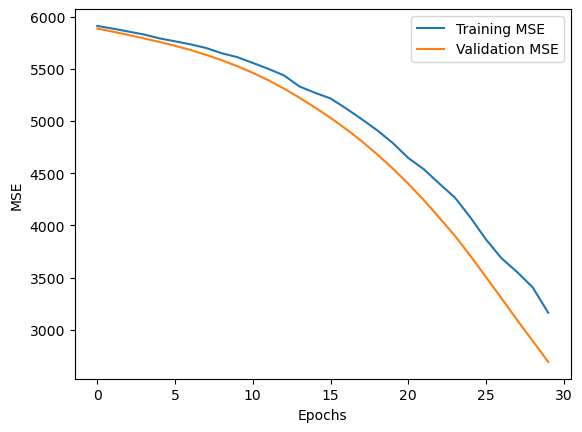

In [170]:
# 그래프 시각화
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 1-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

XGBoostRegressor와 딥러닝 모델의 평균 제곱 오차(MSE)를 비교하여 더 낮은 성능을 보이는 모델을 선택하고, 그 결과를 출력하는 코드를 작성하세요.

In [171]:
# 라이브러리 임포트
from sklearn.metrics import mean_squared_error
# 모델 예측
dl_pred = dl_model.predict(X_valid_scaled)
# mse값 구하기
dl_mse = mean_squared_error(y_valid, dl_pred)
xgb_mse = mean_squared_error(y_valid, xgb_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [172]:
print(f'deep learning : {dl_mse}, xgboost : {xgb_mse}')

deep learning : 2692.62939453125, xgboost : 193.62962341308594
